# Hafta 6 — ADD Çözücüler ve Sonlu Fark Yöntemleri (Capstone)

> **Sıfırdan Sayısal Yöntemler** · Saf NumPy + Matplotlib

Büyük final. **Adi diferansiyel denklemleri (ADD)** $\frac{d\mathbf{y}}{dt} = f(t,\mathbf{y})$ çözüyoruz — fiziğin, biyolojinin ve mühendisliğin dili — sonra sonlu farklarla çözülen **sınır-değer problemlerine** dönüyoruz; bu da doğrudan 3. haftanın lineer çözücülerine bağlanır.

1. **Euler yöntemi** ve yerel vs. küresel kesme hatası.
2. Klasik **RK4** ile zirveye ulaşan **Runge–Kutta** yöntemleri.
3. **Uyarlamalı adım kontrolü** (RK45 / Dormand–Prince fikri).
4. **Katılık (stiffness)** — açık yöntemlerin neden patladığı ve *örtük* yöntemlerin (Geri Euler) bizi nasıl kurtardığı.
5. Sonlu farklarla **sınır-değer problemleri** → bir lineer sistem (3. hafta geri döner).

Bu hafta tüm dersi birleştirir: ADD integrasyonu **kuadratür** (5. hafta) fikirlerini, **1. haftadan** hata analizini, örtük adımların içindeki kök bulmayı (**2. hafta**) ve sınır-değer problemleri için **lineer çözücüleri** (3. hafta) kullanır.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (8, 4.5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3


## 1. Euler yöntemi

En basit şema. Çözümü yerel eğimi izleyerek yaklaşıklayın:

$$ \mathbf{y}_{n+1} = \mathbf{y}_n + h\, f(t_n, \mathbf{y}_n). $$

Adım başına **yerel kesme hatası** $\mathcal{O}(h^2)$'dir, ama hatalar $\mathcal{O}(1/h)$ adım boyunca birikir; bu da $\mathcal{O}(h)$ — *birinci mertebe* — küresel hata verir. $h$'yi yarılamak hatayı yalnızca yarılar: can sıkıcı derecede yavaş.


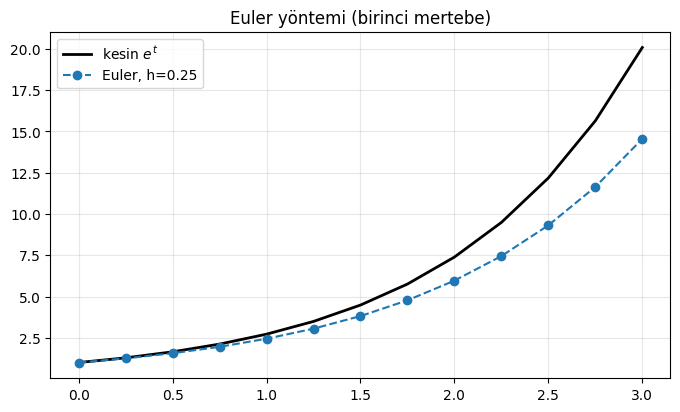

t=3'te hata: 5.533621694820816


In [2]:
def euler(f, t0, y0, tf, h):
    ts = np.arange(t0, tf + 0.5*h, h)
    ys = np.zeros((len(ts),) + np.shape(y0))
    ys[0] = y0
    for n in range(len(ts)-1):
        ys[n+1] = ys[n] + h * f(ts[n], ys[n])
    return ts, ys

# Test problemi y' = y, y(0)=1, kesin çözüm e^t.
f = lambda t, y: y
ts, ys = euler(f, 0, 1.0, 3.0, 0.25)
fig, ax = plt.subplots()
ax.plot(ts, np.exp(ts), "k", lw=2, label="kesin $e^t$")
ax.plot(ts, ys, "o--", label="Euler, h=0.25")
ax.set_title("Euler yöntemi (birinci mertebe)"); ax.legend(); plt.show()
print("t=3'te hata:", abs(ys[-1] - np.exp(3)))


## 2. Runge–Kutta yöntemleri

Euler eğimi adım başına bir kez örnekler. **Runge–Kutta** yöntemleri eğimi adım içinde birkaç kez örnekleyip birleştirir — tıpkı kuadratürün integrandı birkaç noktada örneklemesi gibi. Klasik **RK4** dört eğim değerlendirmesi kullanır:

$$
\begin{aligned}
k_1 &= f(t_n, y_n), & k_2 &= f(t_n + \tfrac h2, y_n + \tfrac h2 k_1),\\
k_3 &= f(t_n + \tfrac h2, y_n + \tfrac h2 k_2), & k_4 &= f(t_n + h, y_n + h k_3),\\
y_{n+1} &= y_n + \tfrac h6 (k_1 + 2k_2 + 2k_3 + k_4). &&
\end{aligned}
$$

**Dördüncü mertebedir**: $h$'yi yarılamak hatayı $16\times$ azaltır. Değerlendirme başına doğruluk Euler'den çok daha iyidir.


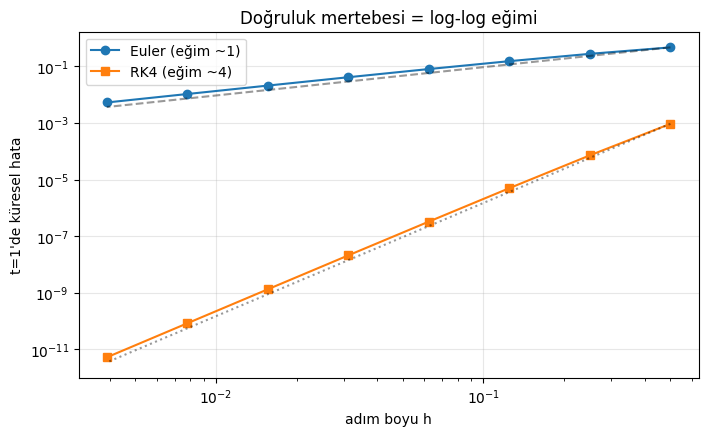

In [3]:
def rk4(f, t0, y0, tf, h):
    ts = np.arange(t0, tf + 0.5*h, h)
    ys = np.zeros((len(ts),) + np.shape(y0))
    ys[0] = y0
    for n in range(len(ts)-1):
        t, y = ts[n], ys[n]
        k1 = f(t, y)
        k2 = f(t + h/2, y + h/2 * k1)
        k3 = f(t + h/2, y + h/2 * k2)
        k4 = f(t + h, y + h * k3)
        ys[n+1] = y + h/6 * (k1 + 2*k2 + 2*k3 + k4)
    return ts, ys

# Yakınsama çalışması: Euler ve RK4 için h'ye karşı küresel hata.
hs = 0.5 ** np.arange(1, 9)
hata_euler, hata_rk4 = [], []
for h in hs:
    _, ye = euler(f, 0, 1.0, 1.0, h); hata_euler.append(abs(ye[-1] - np.e))
    _, yr = rk4(f, 0, 1.0, 1.0, h);   hata_rk4.append(abs(yr[-1] - np.e))

fig, ax = plt.subplots()
ax.loglog(hs, hata_euler, "o-", label="Euler (eğim ~1)")
ax.loglog(hs, hata_rk4, "s-", label="RK4 (eğim ~4)")
ax.loglog(hs, hs*hata_euler[0]/hs[0], "k--", alpha=0.4)
ax.loglog(hs, hs**4*hata_rk4[0]/hs[0]**4, "k:", alpha=0.4)
ax.set_xlabel("adım boyu h"); ax.set_ylabel("t=1'de küresel hata")
ax.set_title("Doğruluk mertebesi = log-log eğimi"); ax.legend(); plt.show()


## 3. Uyarlamalı adım kontrolü

İyi bir integratör sabit $h$ kullanmaz — çözümün pürüzsüz olduğu yerde büyük, hızlı değiştiği yerde küçük adımlar atar. Fikir (RK45 / Dormand–Prince'te kullanılan): adımı **iki farklı mertebede** hesaplamak, farklarını yerel hata kestirimi olarak kullanmak ve bu kestirimi bir toleransa yakın tutmak için $h$'yi ayarlamaktır. İşte kompakt gömülü bir RK çifti (Bogacki–Shampine tarzı, 2. ve 3. mertebe).


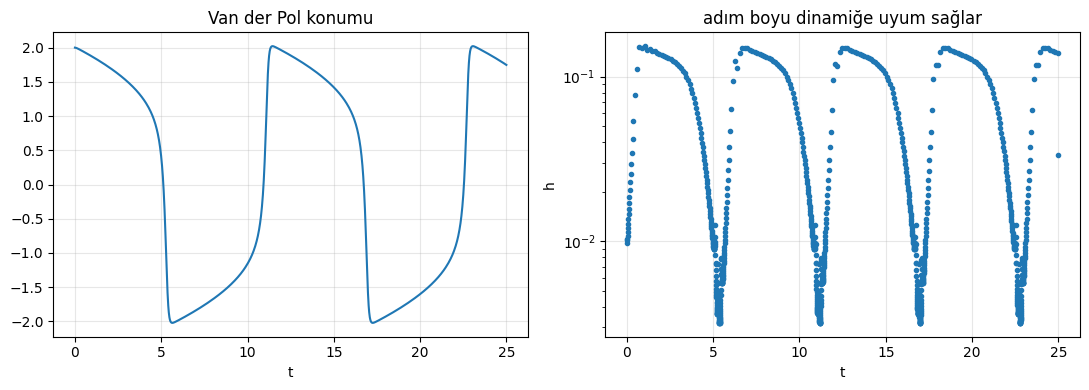

toplam adım sayısı: 882  (sabit ızgara çok daha fazlasını gerektirirdi)


In [4]:
def rk23_uyarlamali(f, t0, y0, tf, tol=1e-6, h0=0.1):
    t, y, h = t0, np.array(y0, dtype=float), h0
    ts, ys, hs = [t], [y.copy()], []
    while t < tf:
        h = min(h, tf - t)
        k1 = f(t, y)
        k2 = f(t + h/2, y + h/2 * k1)
        k3 = f(t + 3*h/4, y + 3*h/4 * k2)
        y3 = y + h/9 * (2*k1 + 3*k2 + 4*k3)          # 3. mertebe kestirim
        k4 = f(t + h, y3)
        y2 = y + h/24 * (7*k1 + 6*k2 + 8*k3 + 3*k4)  # 2. mertebe kestirim
        hata = np.linalg.norm(y3 - y2) + 1e-300
        if hata <= tol:
            t += h; y = y3
            ts.append(t); ys.append(y.copy()); hs.append(h)
        h *= min(2.0, max(0.2, 0.9 * (tol/hata)**(1/3)))   # PI tarzı ayarlama
    return np.array(ts), np.array(ys), np.array(hs)

# Van der Pol salınıcısı: önce pürüzsüz sonra hızlı, uyarlamalılık için ideal.
mu = 5.0
vdp = lambda t, y: np.array([y[1], mu*(1 - y[0]**2)*y[1] - y[0]])
ts, ys, hs = rk23_uyarlamali(vdp, 0, [2.0, 0.0], 25.0, tol=1e-5)

fig, axs = plt.subplots(1, 2, figsize=(11, 4))
axs[0].plot(ts, ys[:, 0]); axs[0].set_title("Van der Pol konumu"); axs[0].set_xlabel("t")
axs[1].semilogy(ts[1:], hs, ".")
axs[1].set_title("adım boyu dinamiğe uyum sağlar"); axs[1].set_xlabel("t"); axs[1].set_ylabel("h")
plt.tight_layout(); plt.show()
print("toplam adım sayısı:", len(hs), " (sabit ızgara çok daha fazlasını gerektirirdi)")


Adım boyunun keskin geçişlerde nasıl *çöktüğüne* ve pürüzsüz fazlarda nasıl *büyüdüğüne* dikkat edin — integratör çabayı akıllıca dağıtır. Bu, üretim ADD çözücülerinin en önemli özelliğidir.

## 4. Katılık (stiffness) ve örtük yöntemler

Bazı sistemler çok farklı zaman ölçeklerine sahiptir. Bu **katı (stiff)** problemler için RK4 gibi açık bir yöntem, **kararlılık** (doğruluk değil) için saçma derecede minik adımlar atmak zorundadır; aksi halde patlar. $y' = -50y$, $y(0)=1$ problemini düşünün; gerçek çözümü yumuşakça $0$'a sönümlenir.


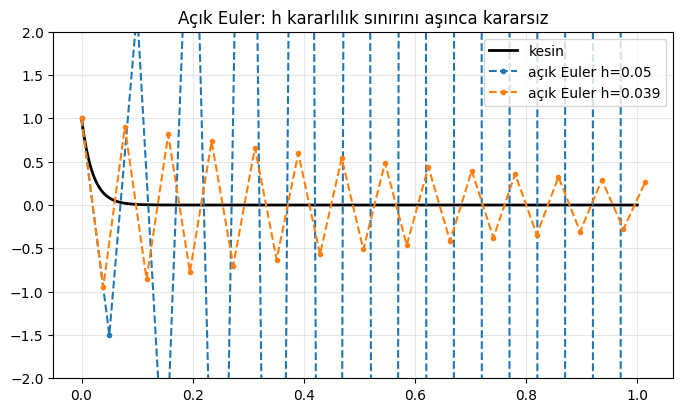

In [5]:
lam = -50.0
kati = lambda t, y: lam * y
kesin_kati = lambda t: np.exp(lam * t)

# Açık Euler yalnızca |1 + h*lam| < 1, yani h < 2/50 = 0.04 ise kararlı.
fig, ax = plt.subplots()
tt = np.linspace(0, 1, 400)
ax.plot(tt, kesin_kati(tt), "k", lw=2, label="kesin")
for h in [0.05, 0.039]:
    ts, ys = euler(kati, 0, 1.0, 1.0, h)
    ax.plot(ts, ys, "o--", ms=3, label=f"açık Euler h={h}")
ax.set_ylim(-2, 2)
ax.set_title("Açık Euler: h kararlılık sınırını aşınca kararsız")
ax.legend(); plt.show()


$h = 0.05$ için açık yöntem büyüyen genlikle salınır — gerçek çözüm önemsiz derecede pürüzsüz olsa bile saf kararsızlık. Çare **Geri (örtük) Euler'dir**:

$$ y_{n+1} = y_n + h\, f(t_{n+1}, y_{n+1}), $$

ki bu her adımda $y_{n+1}$ için bir denklem çözmeyi gerektirir (burada doğrusal; genelde bir kök bulma — 2. hafta!). Geri Euler **koşulsuz kararlıdır**: herhangi bir adım boyu sınırlı kalır.


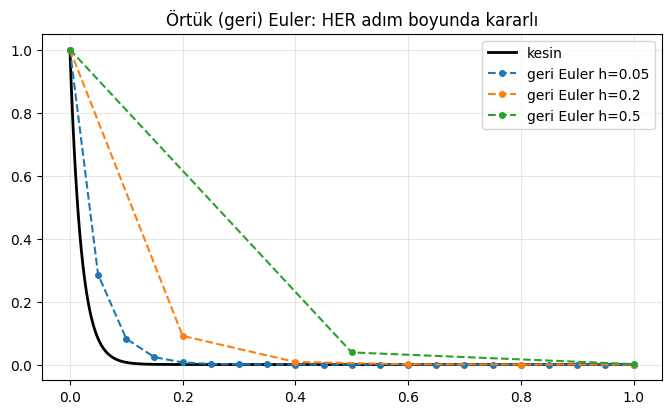

In [6]:
def geri_euler_dogrusal(lam, t0, y0, tf, h):
    ts = np.arange(t0, tf + 0.5*h, h)
    ys = np.zeros(len(ts)); ys[0] = y0
    for n in range(len(ts)-1):
        ys[n+1] = ys[n] / (1 - h*lam)        # (1 - h*lam) y_{n+1} = y_n çöz
    return ts, ys

fig, ax = plt.subplots()
ax.plot(tt, kesin_kati(tt), "k", lw=2, label="kesin")
for h in [0.05, 0.2, 0.5]:
    ts, ys = geri_euler_dogrusal(lam, 0, 1.0, 1.0, h)
    ax.plot(ts, ys, "o--", ms=4, label=f"geri Euler h={h}")
ax.set_title("Örtük (geri) Euler: HER adım boyunda kararlı")
ax.legend(); plt.show()


Devasa bir adımla bile geri Euler iyi davranır. Katılık, örtük çözücülerin var olmasının *asıl* nedenidir — endüstriyel simülasyonlara kadar ölçeklenen bir ders.

## 5. Sonlu farklarla sınır-değer problemleri

Şimdiye dek zamanda ileri yürüdük (başlangıç-değer problemleri). Bir **sınır-değer problemi** *her iki* uçta değer sabitler, örneğin:

$$ -u''(x) = g(x), \quad x\in(0,1), \qquad u(0)=u(1)=0. $$

$N$ iç noktadan oluşan bir ızgarada $u''$'yu merkezi ikinci farkla ayrıklaştırın: $u''(x_i)\approx \frac{u_{i-1}-2u_i+u_{i+1}}{h^2}$. Sonuç **üç köşegenli bir lineer sistemdir** $A\mathbf{u} = \mathbf{g}$ — ve onu 3. haftanın çarpanlamalarıyla çözeriz. Tüm ders burada döngüyü kapatır.


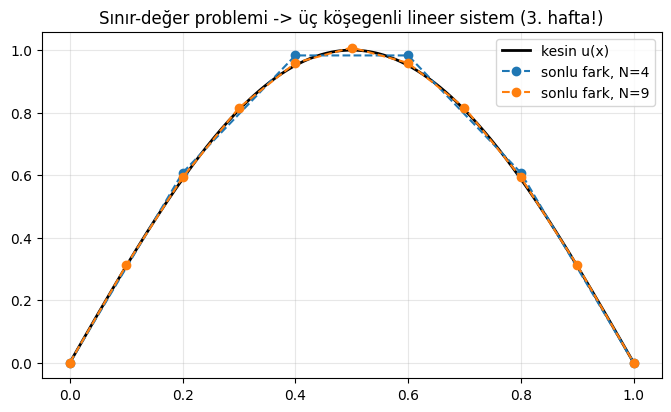

In [7]:
def poisson_svp_coz(g, N):
    h = 1.0 / (N + 1)
    x = np.linspace(0, 1, N + 2)
    xi = x[1:-1]                                   # iç noktalar
    # -u'' için (1/h^2) * tridiag(-1, 2, -1) operatörünü kur.
    ana = 2*np.ones(N); kose = -1*np.ones(N-1)
    A = (np.diag(ana) + np.diag(kose, 1) + np.diag(kose, -1)) / h**2
    b = g(xi)
    u_ic = np.linalg.solve(A, b)
    u = np.concatenate(([0.0], u_ic, [0.0]))
    return x, u

# Üretilmiş çözüm: u(x) = sin(pi x)  =>  -u'' = pi^2 sin(pi x).
g = lambda x: np.pi**2 * np.sin(np.pi * x)
u_kesin = lambda x: np.sin(np.pi * x)

fig, ax = plt.subplots()
xf = np.linspace(0, 1, 400)
ax.plot(xf, u_kesin(xf), "k", lw=2, label="kesin u(x)")
for N in [4, 9]:
    x, u = poisson_svp_coz(g, N)
    ax.plot(x, u, "o--", label=f"sonlu fark, N={N}")
ax.set_title("Sınır-değer problemi -> üç köşegenli lineer sistem (3. hafta!)")
ax.legend(); plt.show()


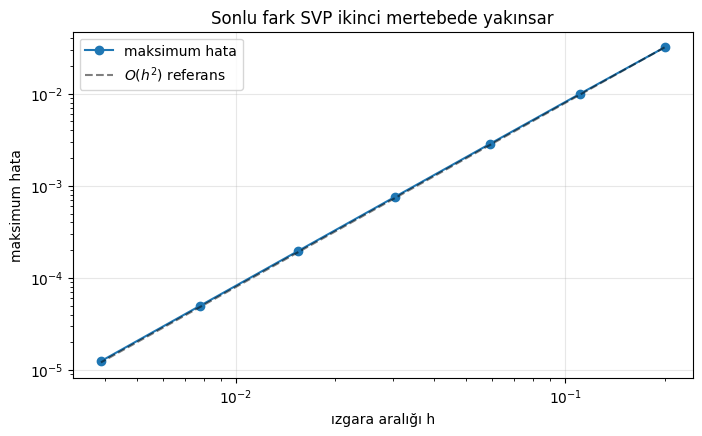

In [8]:
# İkinci mertebe yakınsamayı doğrula: hata h^2 gibi ölçeklenmeli.
Ns = [4, 8, 16, 32, 64, 128, 256]
hatalar, hs = [], []
for N in Ns:
    x, u = poisson_svp_coz(g, N)
    hatalar.append(np.max(np.abs(u - u_kesin(x))))
    hs.append(1.0/(N+1))

fig, ax = plt.subplots()
ax.loglog(hs, hatalar, "o-", label="maksimum hata")
ax.loglog(hs, np.array(hs)**2 * hatalar[0]/hs[0]**2, "k--", alpha=0.5, label=r"$O(h^2)$ referans")
ax.set_xlabel("ızgara aralığı h"); ax.set_ylabel("maksimum hata")
ax.set_title("Sonlu fark SVP ikinci mertebede yakınsar"); ax.legend(); plt.show()


## Ders sentezi

Bu capstone, dersin her ipliğini birbirine dokudu:

- **Hata analizi (H1)** adım boylarının neden sweet spot'u olduğunu ve kararlılığın neden önemli olduğunu anlattı.
- **Kök bulma (H2)** her örtük ADD adımının içinde yaşar.
- **Lineer sistemler (H3)** üç köşegenli SVP ayrıklaştırmasını çözer.
- **İnterpolasyon (H4)** Runge–Kutta'nın çok aşamalı eğim örneklemesinin altında yatar.
- **Kuadratür (H5)** her zaman-adımlama şemasının arkasındaki integral biçimidir.

Sayısal yöntemler bir hileler torbası değildir — sürekli matematiği sonlu, kararlı, yakınsak hesaplamaya dönüştürmeyle ilgili tek ve tutarlı bir disiplindir.

---

## Alıştırmalar

**1. (Mertebe doğrulaması.)** RK4'ün dördüncü, Euler'in birinci mertebe olduğunu doğrusal olmayan $y' = -y^2$, $y(0)=1$ (kesin $y=1/(1+t)$) problemi üzerinde deneysel doğrulayın.

**2. (Simplektik integratörler.)** Harmonik salınıcı için açık Euler, RK4 ve simplektik *leapfrog* yöntemindeki enerji kaymasını uzun zamanlar boyunca karşılaştırın. Leapfrog'un yalnızca ikinci mertebe olmasına rağmen enerjiyi neden koruduğunu açıklayın.

**3. (Kararlılık bölgeleri.)** Açık Euler ve RK4 için karmaşık $h\lambda$-düzleminde mutlak kararlılık bölgesini çizin. Gözlemlediğiniz katı patlamayla ilişkilendirin.

**4. (Örtük doğrusal olmayan.)** Doğrusal olmayan katı bir ADD için geri Euler'i, adım başına denklemi çözmek üzere 2. haftadan Newton çözücünüzü kullanarak kodlayın. Koşulsuz kararlılığı doğrulayın.

**5. (Değişken katsayılı SVP.)** Sonlu fark çözücüsünü, matrisi üç köşegenli tutarak değişken $a(x)$ ile $-(a(x)u')' = g(x)$'e genişletin. Üretilmiş bir çözümde ikinci mertebe yakınsamayı doğrulayın.

**6. (2B Poisson.)** SVP çözücüsünü, 5-noktalı şablonla birim kare üzerinde $-\nabla^2 u = g$'ye genelleştirin. Oluşan seyrek sistemi çözüp `plt.imshow` ile görselleştirin.
